# AI Triage & Intake Assistant for Small Clinics

This project is a Canada-focused healthcare analytics prototype that uses synthetic patient intake data to classify patients by risk level, visit urgency, and recommended clinic actions. It demonstrates practical skills in Python, pandas, data visualization, and rule-based decision systems.

## Objective

Small clinics often need a fast and structured way to prioritize incoming patients and manage appointment demand.

This project simulates Canadian patient intake data and applies multi-factor triage logic using age, symptoms, pain level, and breathing issues to classify patients by risk level, visit urgency, and recommended clinic action.

The goal is to demonstrate practical healthcare analytics, workflow automation, and dashboard reporting using Python.

## Imports

In [16]:
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

## Generate Synthetic Patient Data

In [7]:
provinces = [
    "Ontario",
    "Quebec",
    "British Columbia",
    "Alberta",
    "Manitoba",
    "Saskatchewan",
    "Nova Scotia",
    "New Brunswick",
    "Newfoundland and Labrador",
    "Prince Edward Island"
]

symptoms = [
    "Fever",
    "Chest Pain",
    "Cough",
    "Headache",
    "Fatigue",
    "Shortness of Breath",
    "Abdominal Pain",
    "Dizziness",
    "Nausea",
    "Back Pain"
]

breathing = ["Yes", "No"]

dates = [
    "2026-04-01",
    "2026-04-05",
    "2026-04-10",
    "2026-04-15",
    "2026-04-20",
    "2026-04-25"
]

patients = []

for i in range(50):
    patient = {
        "Patient_ID": f"P{i+1:03}",
        "Intake_Date": random.choice(dates),
        "Age": random.randint(18, 90),
        "Province": random.choice(provinces),
        "Symptom": random.choice(symptoms),
        "Pain_Level": random.randint(1, 10),
        "Breathing_Issue": random.choice(breathing)
    }

    patients.append(patient)

df = pd.DataFrame(patients)

df.head()

,Patient_ID,Intake_Date,Age,Province,Symptom,Pain_Level,Breathing_Issue
0,P001,2026-04-05,46,British Columbia,Chest Pain,9,Yes
1,P002,2026-04-20,72,Ontario,Fever,2,Yes
2,P003,2026-04-05,82,Prince Edward Island,Fever,9,Yes
3,P004,2026-04-25,87,Nova Scotia,Headache,8,No
4,P005,2026-04-01,38,Nova Scotia,Shortness of Breath,5,Yes


## Feature Engineering & Triage Logic

In [8]:
def risk_group(row):
    if row["Pain_Level"] >= 8:
        return "Critical"
    elif row["Breathing_Issue"] == "Yes" and row["Age"] >= 65:
        return "Critical"
    elif row["Symptom"] == "Chest Pain" and row["Age"] >= 50:
        return "Critical"
    elif row["Pain_Level"] >= 5:
        return "Higher Risk"
    elif row["Breathing_Issue"] == "Yes":
        return "Higher Risk"
    else:
        return "Standard Risk"


def visit_type(row):
    if row["Symptom"] == "Chest Pain":
        return "Urgent Visit"
    elif row["Symptom"] == "Shortness of Breath":
        return "Urgent Visit"
    elif row["Symptom"] in ["Fever", "Dizziness", "Nausea"]:
        return "Same Day Visit"
    else:
        return "Routine Visit"


def clinic_action(row):
    if row["Risk_Group"] == "Critical":
        return "Send Immediately"
    elif row["Visit_Type"] == "Urgent Visit":
        return "Nurse Review"
    elif row["Risk_Group"] == "Higher Risk":
        return "Priority Booking"
    elif row["Visit_Type"] == "Same Day Visit":
        return "Same Day Appointment"
    else:
        return "Routine Appointment"


df["Risk_Group"] = df.apply(risk_group, axis=1)
df["Visit_Type"] = df.apply(visit_type, axis=1)
df["Clinic_Action"] = df.apply(clinic_action, axis=1)

df.head()

,Patient_ID,Intake_Date,Age,Province,Symptom,Pain_Level,Breathing_Issue,Risk_Group,Visit_Type,Clinic_Action
0,P001,2026-04-05,46,British Columbia,Chest Pain,9,Yes,Critical,Urgent Visit,Send Immediately
1,P002,2026-04-20,72,Ontario,Fever,2,Yes,Critical,Same Day Visit,Send Immediately
2,P003,2026-04-05,82,Prince Edward Island,Fever,9,Yes,Critical,Same Day Visit,Send Immediately
3,P004,2026-04-25,87,Nova Scotia,Headache,8,No,Critical,Routine Visit,Send Immediately
4,P005,2026-04-01,38,Nova Scotia,Shortness of Breath,5,Yes,Higher Risk,Urgent Visit,Nurse Review


## Dashboard Charts

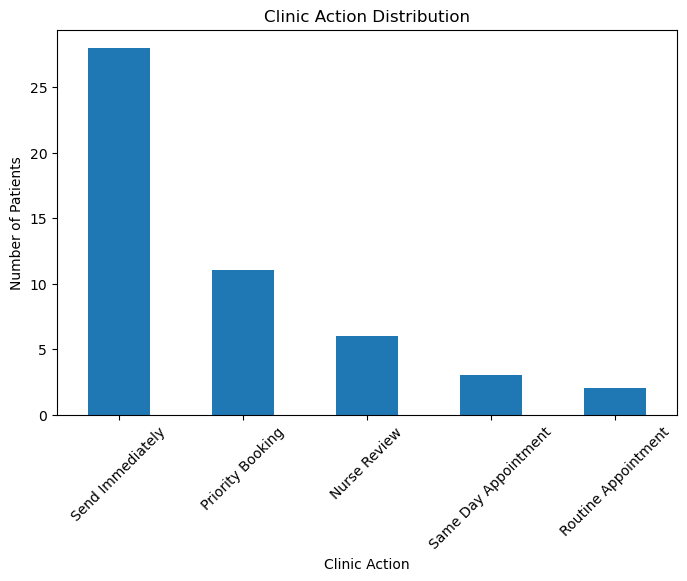

In [9]:
df["Clinic_Action"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Clinic Action Distribution")
plt.xlabel("Clinic Action")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

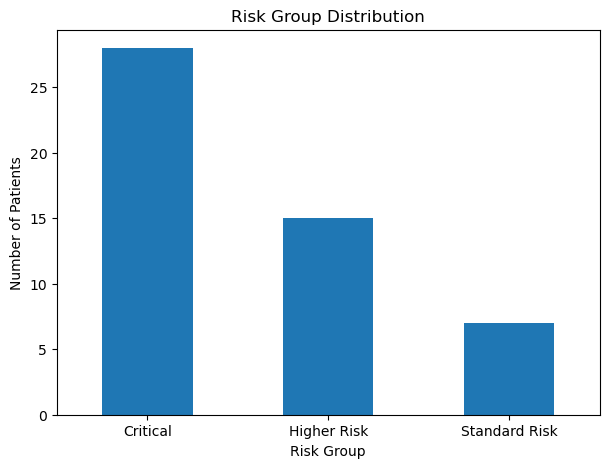

In [10]:
df["Risk_Group"].value_counts().plot(kind="bar", figsize=(7,5))

plt.title("Risk Group Distribution")
plt.xlabel("Risk Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

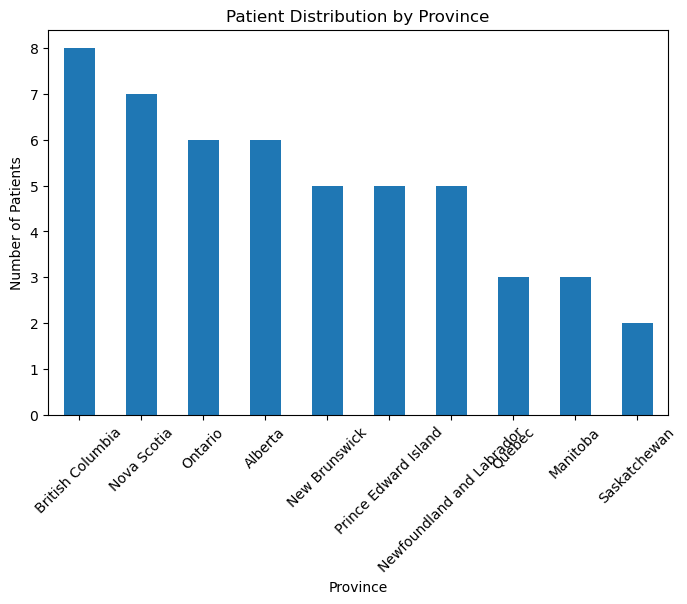

In [11]:
df["Province"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Patient Distribution by Province")
plt.xlabel("Province")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

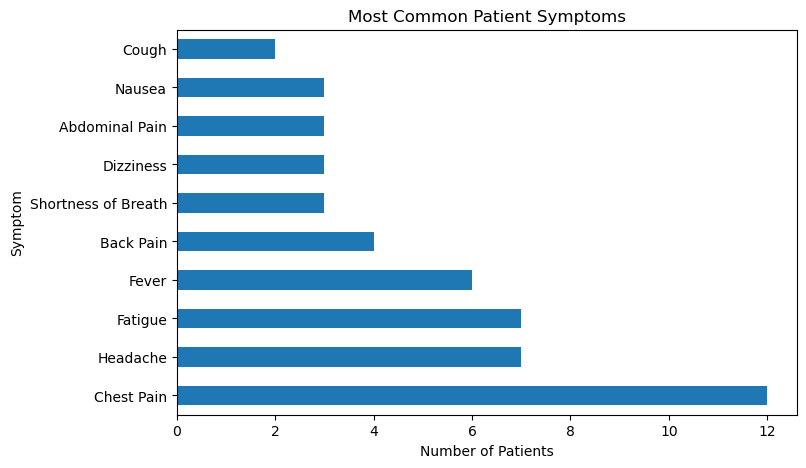

In [12]:
df["Symptom"].value_counts().plot(kind="barh", figsize=(8,5))

plt.title("Most Common Patient Symptoms")
plt.xlabel("Number of Patients")
plt.ylabel("Symptom")
plt.show()

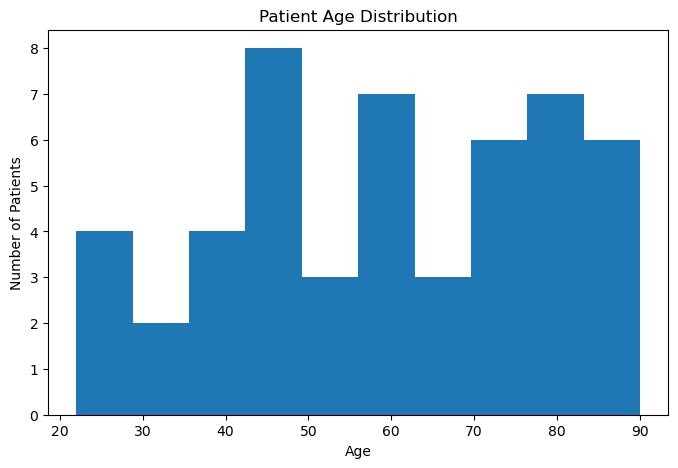

In [13]:
df["Age"].plot(kind="hist", bins=10, figsize=(8,5))

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

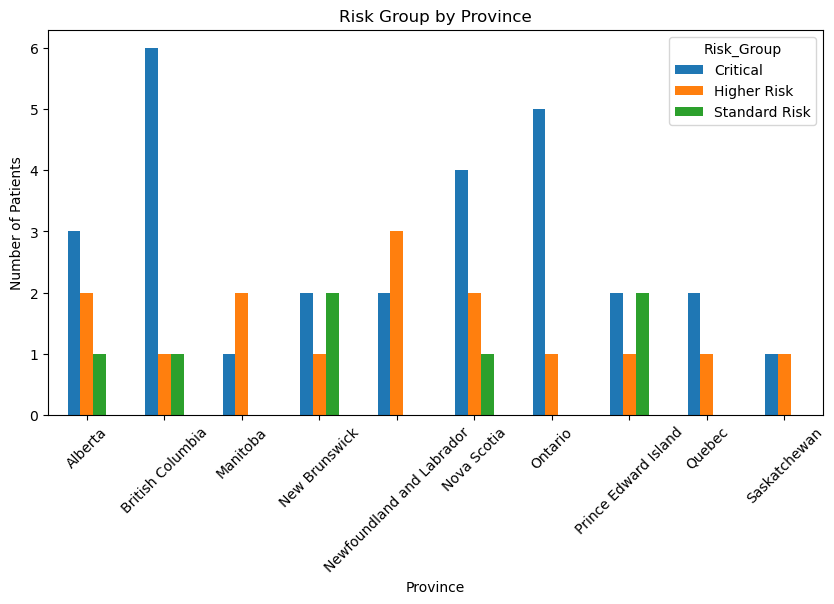

In [14]:
pd.crosstab(df["Province"], df["Risk_Group"]).plot(kind="bar", figsize=(10,5))

plt.title("Risk Group by Province")
plt.xlabel("Province")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

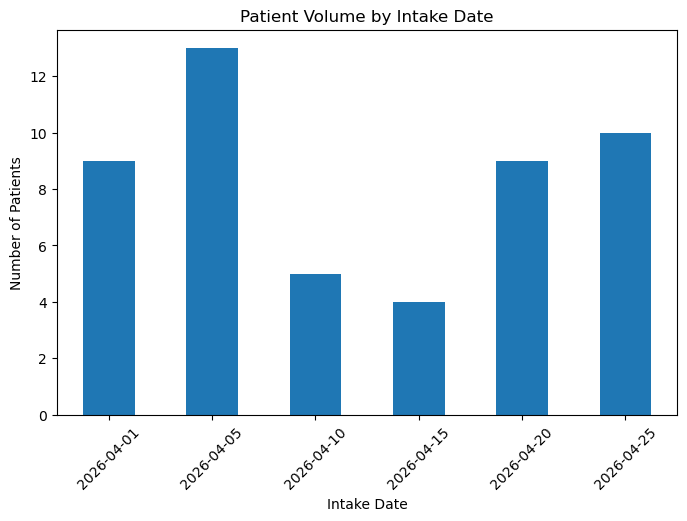

In [15]:
df["Intake_Date"].value_counts().sort_index().plot(kind="bar", figsize=(8,5))

plt.title("Patient Volume by Intake Date")
plt.xlabel("Intake Date")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

## Key Insights

- Send Immediately became the most common clinic action after upgrading the triage rules.
- Critical was the largest patient risk category in the updated simulation.
- Multi-factor rules using age, symptoms, pain level, and breathing issues increased urgent classifications.
- Higher-acuity patients represented a larger share of simulated clinic demand after model improvements.
- Geographic patient demand remained distributed across multiple Canadian provinces.
- The upgraded logic better reflects realistic clinic intake prioritization workflows.

## Limitations

- This project uses synthetic (simulated) patient data for educational and portfolio purposes.
- The triage engine uses simplified rule-based logic and does not represent real clinical decision protocols.
- Results are not medical advice, diagnosis, or treatment recommendations.
- Patient risk classifications are generated from limited variables such as age, symptom, pain level, and breathing issues.
- Real healthcare triage systems would require validated medical guidelines, clinician oversight, and privacy protections.
- Provincial patient counts and visit dates are randomly generated and do not reflect actual Canadian healthcare demand.
- Additional real-world factors such as medical history, medications, wait times, and vital signs were not included.

Future Improvements

- Expand the dataset to include all Canadian provinces and territories.
- Add more clinical variables such as heart rate, temperature, oxygen level, and blood pressure.
- Introduce timestamps with hourly intake patterns and seasonal demand trends.
- Build an interactive Streamlit web application for clinic staff use.
- Export the dataset into Tableau for advanced dashboard reporting.
- Replace rule-based logic with machine learning models trained on validated healthcare data.
- Store patient records in a SQL database for search, reporting, and analytics.
- Add user authentication and privacy controls for production environments.

## Export Dataset for Tableau

In [17]:
df.to_csv("tableau_clinic_data_v2.csv", index=False)

In [18]:
import os
os.listdir()

['tableau_clinic_data_v2.csv',
 'AI_Triage_Intake_Assistant_Canada.ipynb',
 '.ipynb_checkpoints']